<style>
body { text-autospace: normal; }
h3 { margin-top: 4em !important; }
h4 { margin-top: 2.4em !important; }
h5 { margin-top: 0.3em !important; color: #555 !important; font-weight: 400 !important; }
</style>

### Evo 2 の内部表現をスパースオートエンコーダで読む
##### 第 3 部 — DSSP・配列書き換え・プロファージ間の比較
***

第 1 部で見た二次構造と外来配列の特徴を, 数値で確かめます. 二次構造の特徴は, 立体構造から DSSP で求めた二次構造と残基ごとに照合します. 外来配列の特徴は, 配列を書き換えたときに発火がどう変わるかと, 別のプロファージでも発火するかで調べます.

| 節 | 題材 | 内容 |
|---|---|---|
| 02 | Fig. 4d | 二次構造の特徴を DSSP と照合する |
| 03 | Ext Fig. 7c | スペーサーとリピートを書き換えて手がかりを絞る |
| 04 | Ext Fig. 7b | ほかのプロファージでの発火を比べる |

### 01. 準備
***

`evo2_sae` を入れ, 検証に使う活性を用意します. 大腸菌ゲノム NC_000913.3 の 4,162,560-4,193,280, 30,720 塩基ぶんを配布した活性行列から取り出します. この範囲の外にある座位も同じ行列から引きます. 書き換えた配列を通すときだけ, SAE のチェックポイントを直接使います.

| ファイル | サイズ | 内容 |
|---|---:|---|
| `scramble.pt` | 184 MB | CRISPR アレイを 16 通りに書き換えて埋め込んだもの |
| `proteins.json` | 5 KB | 7 つのタンパク質の座標と DSSP |
| `ecoli.bed` | 0.2 MB | ゲノム全体の遺伝子座標 |
| `ecoli_values.f16` ほか 2 本 | 2.4 GB | SAE の活性行列 |

In [1]:
# Colab には torch と huggingface_hub が入っている. 手元で動かす場合は別途入れる
%pip install -q git+https://github.com/GenAIBio/evo2-sae-handson

import numpy as np
import pandas as pd
import torch
from huggingface_hub import hf_hub_download

import evo2_sae
evo2_sae.setup("https://huggingface.co/datasets/suzuki-2001/evo2-sae-handson/resolve/main")

# SAE. 配列を書き換える節で使う
ckpt = hf_hub_download("Goodfire/Evo-2-Layer-26-Mixed", "sae-layer26-mixed-expansion_8-k_64.pt")
sd = torch.load(ckpt, map_location="cpu")
W, b_enc = sd["_orig_mod.W"].float(), sd["_orig_mod.b_enc"].float()

K = 64  # チェックポイントの k

def batch_topk(a, k):
    # L x 32768 個の活性から, 大きい順に k x L 個だけ残す
    floor = torch.topk(a.flatten(), k * a.shape[0]).values.min()
    return torch.where(a >= floor, a, torch.zeros_like(a))

# 30,720 塩基ぶんの活性. 配布した行列から取り出す
chrom = "NC_000913.3"
region = evo2_sae.Region.from_genome(chrom, 4_162_560, 4_193_280)

# 論文が挙げている特徴のインデックス
F_HELIX, F_SHEET = 28741, 22326  # Fig. 4d
F_PROPHAGE = 19746  # Fig. 4b

sae-layer26-mixed-expansion_8-k_64.pt: reconstructing file:   0%|          |  0.00B /  537MB            

sae-layer26-mixed-expansion_8-k_64.pt: downloading bytes:           |  0.00B            

### 02. 二次構造との対応を測る (Fig. 4d)
***

論文が $\alpha$ ヘリックスと $\beta$ シートに対応するものとして挙げている f/28741 と f/22326 を, 立体構造から DSSP で求めた二次構造と照合します.

残基 $i$ に対応するゲノム座標は $p_i(k) = \mathrm{start} + 3(i-1) + k$ の 3 つです ($k = 0, 1, 2$). この 3 塩基の平均を残基ごとの活性とし, どちらかの特徴が 0 でない残基を発火した残基と数えます. 対象の 7 遺伝子はいずれも + 鎖にあります.

`proteins.json` には各タンパク質の DSSP 3 状態 (H = ヘリックス, E = シート, C = それ以外) が入っています. 発火した残基がどちらの二次構造だったかを数えます.

In [2]:
PROTEINS = evo2_sae.proteins()  # ORF の座標と DSSP. 7 つとも + 鎖

rows = []
for gene, p in PROTEINS.items():
    dssp = np.array(list(p["ss3"][:p["n_res"]]))
    row = {
        "gene": gene,
        "残基": len(dssp),
        "H": f"{(dssp == 'H').mean():.0%}",
        "E": f"{(dssp == 'E').mean():.0%}",
    }
    for feature, label in ((F_HELIX, "H"), (F_SHEET, "E")):
        fired = region.residue_acts(gene, feature) > 0
        row[f"f/{feature} 発火"] = f"{fired.mean():.0%}"
        row[f"うち {label}"] = f"{(dssp[fired] == label).mean():.0%}" if fired.any() else "—"
    rows.append(row)
pd.DataFrame(rows)

downloading proteins.json


,gene,残基,H,E,f/28741 発火,うち H,f/22326 発火,うち E
0,tufB,394,24%,37%,10%,82%,25%,71%
1,rpoB,1342,33%,25%,19%,81%,23%,59%
2,rpoC,1407,39%,19%,23%,80%,19%,45%
3,pspA,222,91%,0%,34%,99%,2%,0%
4,ompG,301,1%,66%,1%,33%,14%,98%
5,crp,210,38%,30%,17%,89%,18%,73%
6,groL,548,51%,18%,22%,92%,17%,62%


f/28741 が発火した残基は, その 80% から 99% がヘリックスです. タンパク質全体でのヘリックスの割合は 24-51% なので, 発火した残基はヘリックスに偏っています. f/22326 も同じで, 発火した残基の多くがシートです.

*pspA* はシートが 1 残基もなく, f/22326 はほとんど発火しません. *ompG* はヘリックスが 1% しかなく, f/28741 の発火がそこに集中します. この 2 つが対照になります.

DSSP は立体構造から計算した指標で, Evo 2 が受け取るのは塩基配列だけです. その内部表現から特徴を 1 つ, すなわち 4096 次元空間の 1 方向への射影を取り出します. 上の表のとおり, この 1 方向が折りたたみ後の二次構造に対応します.

### 03. スペーサーとリピートを書き換える (Ext Fig. 7c)
***

論文が外来由来の配列に対応する特徴として挙げている f/19746 は, プロファージと, CRISPR アレイのスペーサーで発火します. スペーサーは過去に侵入したファージなどから取り込まれた断片で, 29 bp のリピートと交互に並んでいます.

この特徴が読んでいる手がかりは 2 つ考えられます. スペーサーが外来 DNA 由来であること自体か, リピートに挟まれているという並び方かです.

論文は Extended Data Fig. 7c で同じことを調べているので, その操作を組み立てて確かめます. アレイを右端に含む 16,384 bp のウィンドウを作り, アレイの中だけを書き換えて Evo 2 に通しました. アレイより前はどれも同じ配列です.

| | 操作 |
|---|---|
| (i) | スペーサー 12 個を, それぞれ自身の塩基を並べ替えたものに置き換える |
| (ii) | リピート 13 個すべてを, 並べ替えた同じ 1 本に置き換える |
| (iii) | リピート 13 個を, それぞれ自身の塩基を並べ替えたものに置き換える |
| (iv) | 天然のまま |

置き換えるのは元の塩基を並べ替えた配列です. 断片の長さも位置も, その前後の配列もそのままで, 変わるのは並び順だけです. (i) と (iii) は各断片を自身の塩基で並べ替えるので, A/C/G/T の個数も元と一致します. (ii) は 13 か所に同じ 1 本を置くので, 同じものが等間隔に 13 回並ぶという配置が残り, (iii) はそれも崩します. (ii) が置く 1 本は, 13 個の多数決で決めたコンセンサスを並べ替えたものです. 左端の 3 個はここから 1-3 塩基ずれています. 並べ替え方を変えると結果も変わるので, (i)-(iii) はそれぞれ乱数を変えて 5 通り用意しました.

16 本ぶんの埋め込みが `scramble.pt` です.

downloading scramble.pt


downloading ecoli.bed


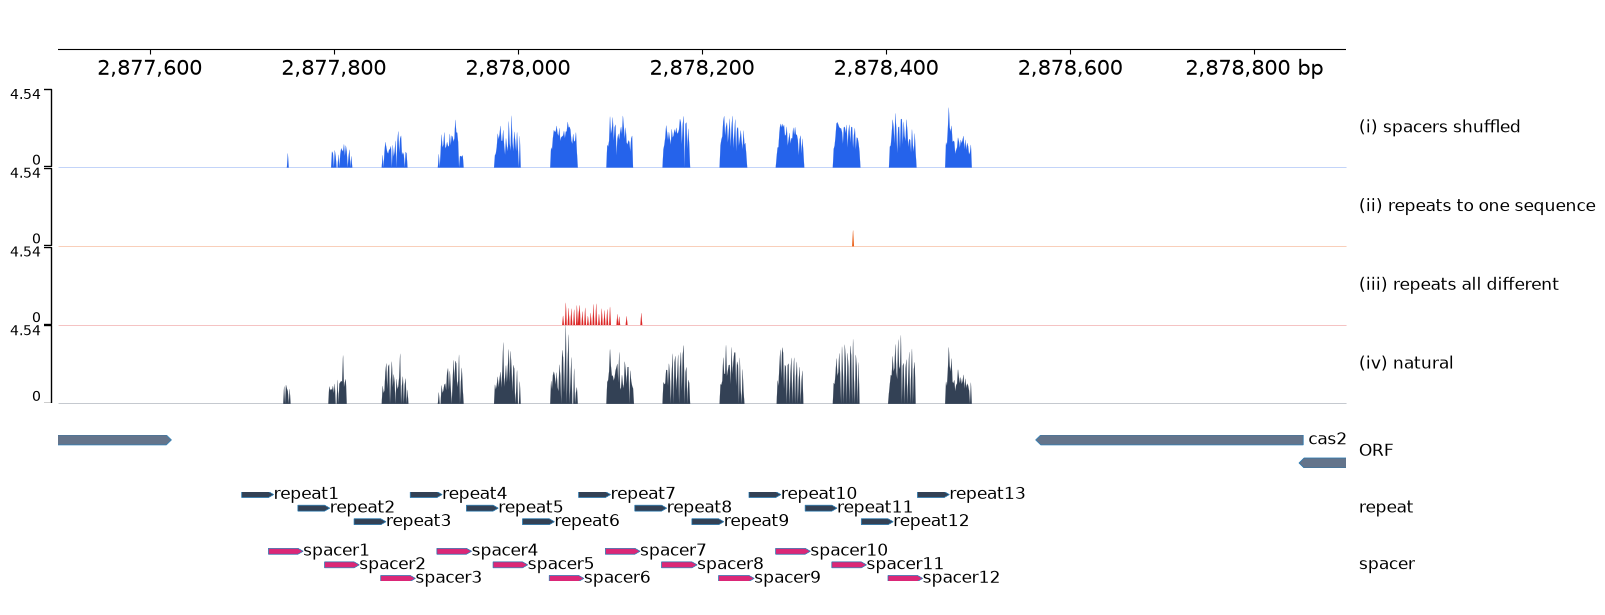

In [3]:
scramble = torch.load(evo2_sae.download("scramble.pt"), map_location="cpu")
lo, hi = scramble["start"], scramble["end"]

VARIANTS = [
    ("spacers_shuffled", "#2563eb", "(i) spacers shuffled"),
    ("repeats_constant", "#ea580c", "(ii) repeats to one sequence"),
    ("repeats_varying", "#dc2626", "(iii) repeats all different"),
    ("natural", "#334155", "(iv) natural"),
]

def encode(name):
    # SAE と同じ 2 段. 配列 1 本を 1 つの入力として BatchTopK をかける
    a = torch.relu(scramble[name].float() @ W + b_enc)
    return batch_topk(a, K)[:, F_PROPHAGE].numpy()

SEEDS = range(scramble["draws"])

tracks = {}
for name, _, _ in VARIANTS:
    if name == "natural":
        tracks[name] = [encode(name)]
    else:
        tracks[name] = [encode(f"{name}_{seed}") for seed in SEEDS]

# 乱数を変えた 5 本があるので, トラックにはその中央値を表示する
columns = np.stack([np.median(tracks[name], axis=0) for name, _, _ in VARIANTS], axis=1)

evo2_sae.Region.from_matrix(chrom, lo, columns).show(
    [(i, colour, label) for i, (_, colour, label) in enumerate(VARIANTS)],
    top=float(columns.max()),
)

上から順に (i)・(ii)・(iii)・(iv) です. スペーサーごとの平均を乱数ごとに並べます.

In [4]:
spacers = list(evo2_sae.overlapping(lo, hi, "spacer"))

def spacer_means(track):
    return np.array([track[r["start"] - lo:r["end"] - lo].mean() for r in spacers])

rows = []
for name, _, label in VARIANTS:
    for seed, track in enumerate(tracks[name]):
        means = spacer_means(track)
        row = {
            "配列": label,
            "乱数": "-" if name == "natural" else seed,
            "平均": round(float(means.mean()), 2),
        }
        row.update({f"{j + 1}": round(float(v), 2) for j, v in enumerate(means)})
        rows.append(row)
pd.DataFrame(rows)

,配列,乱数,平均,1,2,3,4,5,6,7,8,9,10,11,12
0,(i) spacers shuffled,0,1.34,0.00,0.74,0.72,1.29,1.43,2.10,1.68,1.49,1.62,1.47,1.66,1.83
1,(i) spacers shuffled,1,1.33,0.20,0.29,1.18,1.12,1.45,1.73,1.46,1.63,1.79,1.74,1.73,1.69
2,(i) spacers shuffled,2,1.22,0.03,0.39,0.63,0.93,1.08,1.63,1.78,1.45,1.57,1.80,1.78,1.56
3,(i) spacers shuffled,3,1.32,0.11,0.61,0.88,1.07,1.52,1.49,1.71,1.74,1.67,1.52,1.89,1.62
4,(i) spacers shuffled,4,1.32,0.00,0.45,0.98,0.99,1.26,1.45,1.74,1.62,1.88,1.75,1.82,1.87
5,(ii) repeats to one sequence,0,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.03
6,(ii) repeats to one sequence,1,0.31,0.00,0.00,0.00,0.00,0.02,0.09,0.16,0.39,0.21,0.57,0.99,1.26
7,(ii) repeats to one sequence,2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,(ii) repeats to one sequence,3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00
9,(ii) repeats to one sequence,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


(i) は 5 通りとも平均 1.22-1.34 で, 天然配列の 1.20 と変わりません. スペーサーの中身を壊しても発火は残るので, 外来 DNA 由来であること自体は手がかりになっていません.

(ii) と (iii) は中央値がそれぞれ 0.00 と 0.06 で, 発火が消えます. スペーサーが天然配列のままでもリピートを壊すと戻らないので, 手がかりはスペーサーの側ではなくリピートの側にあります.

天然配列でも左端の 2 つは 0.14 と 0.60 と低めです. この 2 つを挟むリピートは配列が崩れており, コンセンサスから 1-3 塩基ずれています. リピートの崩れも活性に表れています.

論文の該当パネルを, こちらの図と同じ並び順で示します.

![Extended Data Fig. 7c](https://raw.githubusercontent.com/GenAIBio/evo2-sae-handson/main/docs/evo2_ext_fig7c.png)

Brixi et al. *Nature* 2026, Extended Data Fig. 7c より. [CC BY-NC-ND 4.0](https://creativecommons.org/licenses/by-nc-nd/4.0/)

スペーサーを並べ替えても発火が残り, リピートを 1 個ずつ並べ替えると消えるという形は, (i) と (iii) で論文と一致します. (iv) の天然配列も同じです.

(ii) だけは再現できませんでした. 論文では先頭 2 つのスペーサーだけが消え, 3 つ目以降は元の高さを保っています. 先頭 2 つが 0 になる点は 5 通りとも一致しますが, 3 つ目以降まで戻ったのは 5 通りのうち 1 通り (乱数 1) だけで, 残る 4 通りは 0.00-0.01 でした. その 1 通りも戻り方が違います.

| スペーサー | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 天然配列 | 0.14 | 0.60 | 1.04 | 1.03 | 1.30 | 1.34 | 1.46 | 1.40 | 1.44 | 1.40 | 1.55 | 1.66 |
| (ii) 乱数 1 | 0.00 | 0.00 | 0.00 | 0.00 | 0.02 | 0.09 | 0.16 | 0.39 | 0.21 | 0.57 | 0.99 | 1.26 |

論文は 3 つ目で元の高さに戻りますが, こちらはアレイを進むにつれてなだらかに上がり, 末尾で天然配列の水準に達します. 論文は置き換えに使った 1 本をどう作ったかを書いていないので, この違いが手続きの差によるものかは判断できません.

(ii) と (iii) の差は, リピートの配列そのものが要るのか, 同じものが規則的に並ぶ配置で足りるのかを分けます. 論文の (ii) は後者を示しています. こちらでは (ii) も消えるためこの差が出ず, 配列と配置のどちらが効いているかはここまでの結果からは決められません.

### 04. ほかのプロファージでも発火するか (Ext Fig. 7b)
***

f/19746 が最も強く発火するのは CPZ-55 です. ほかのプロファージでも発火しますが, 強さと広がりが違います.

geNomad はこのゲノムで 5 領域をプロファージと判定します. K-12 のゲノムにある 9 つのプロファージのうち 5 つ (DLP12, e14, rac, Qin, CPS-53) です.

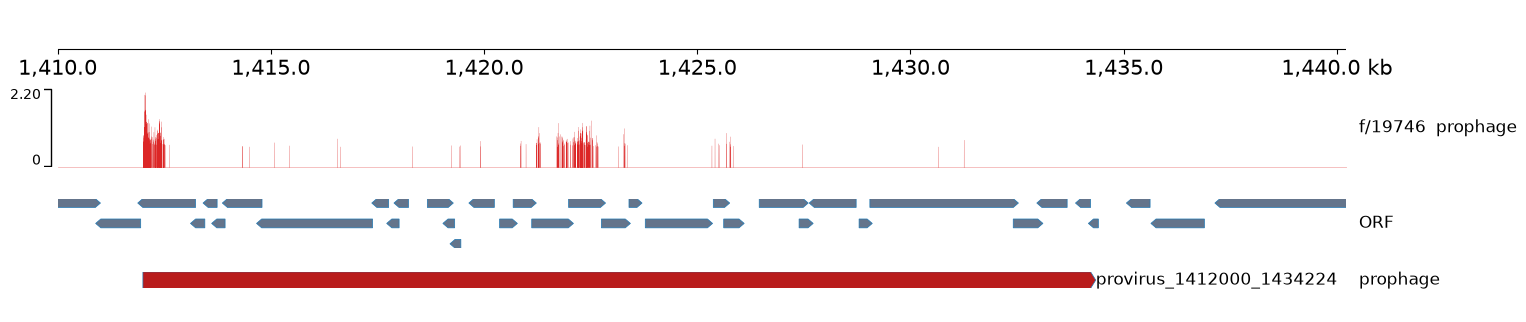

In [5]:
PROPHAGES = {
    "DLP12": (563_848, 584_430),
    "e14": (1_196_867, 1_213_107),
    "rac": (1_412_000, 1_434_224),
    "Qin": (1_627_517, 1_656_149),
    "CPS-53": (2_463_012, 2_476_510),
}

prophage = "rac"  #@param ["DLP12","e14","rac","Qin","CPS-53"]

begin, finish = PROPHAGES[prophage]

# 右側を広めに取るのは, 区間名がトラック名に重ならないようにするため
evo2_sae.Region.from_genome(chrom, begin - 2_000, finish + 6_000).show(
    [(F_PROPHAGE, "#dc2626", f"f/{F_PROPHAGE}  prophage")],
)

ピークは 0.93 から 2.10 で, CPZ-55 の 6.12 に対して 3 分の 1 から 6 分の 1 です. 発火する範囲も違い, CPZ-55 が区間の 47% の塩基で発火するのに対し, 5 領域では 0.1% から 2.1% にとどまります. どの領域でも発火は見られますが, 外来配列として読まれているのは区間の一部です.

論文の Extended Data Fig. 7d は逆の例を挙げています. geNomad がファージと呼んでいない領域でこの特徴が強く発火する例で, そこには integrase や transposase が含まれます. 例は *E. coli* の別の株 2 か所と *A. thiophilum* 1 か所です.

### 参考文献
***

Brixi G, Durrant MG, Ku J, Naghipourfar M, Poli M, Sun G, et al. Genome modelling and design across all domains of life with Evo 2. *Nature* 2026. [doi:10.1038/s41586-026-10176-5](https://doi.org/10.1038/s41586-026-10176-5)

Cunningham H, Ewart A, Riggs L, Huben R, Sharkey L. Sparse autoencoders find highly interpretable features in language models. *arXiv* 2023. [doi:10.48550/arXiv.2309.08600](https://doi.org/10.48550/arXiv.2309.08600)

Xu W, Zhong Q, Lin D, Zuo Y, Dai J, Li G, Cao G. CoolBox: a flexible toolkit for visual analysis of genomics data. *BMC Bioinformatics* 2021. [doi:10.1186/s12859-021-04408-w](https://doi.org/10.1186/s12859-021-04408-w)

Wang X, Kim Y, Ma Q, Hong SH, Pokusaeva K, Sturino JM, Wood TK. Cryptic prophages help bacteria cope with adverse environments. *Nature Communications* 2010. [doi:10.1038/ncomms1146](https://doi.org/10.1038/ncomms1146)